In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "Fluc_erg_WS.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

In [3]:
N = data["N"]
tau = data["tau"]
Eb = data["Eb"]
Eerg = data["Eerg"]
ratio = data["ratio"]
variance = data["variance"]

for i in range(len(N)):
    print(
        f"N={N[i]}, "
        f"τ={tau[i]:.4f}, "
        f"Eb={Eb[i]:.6f}, "
        f"Ergotropy={Eerg[i]:.6f}, "
        f"Ratio={ratio[i]:.6f}, "
        f"Variance={variance[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, Ratio=0.964114, Variance=5.7360130333e-01,Fluctuation w.r.t erg=7.4239187643e-01,Fluctuation w.r.t EB=7.1575014257e-01
N=6, τ=0.4344, Eb=3.629995, Ergotropy=3.569077, Ratio=0.983218, Variance=1.8187600085e+00,Fluctuation w.r.t erg=3.7786079442e-01,Fluctuation w.r.t EB=3.7151950632e-01
N=10, τ=0.3478, Eb=6.304395, Ergotropy=6.233173, Ratio=0.988703, Variance=3.0741364854e+00,Fluctuation w.r.t erg=2.8128877604e-01,Fluctuation w.r.t EB=2.7811097277e-01
N=14, τ=0.2996, Eb=9.026203, Ergotropy=8.948377, Ratio=0.991378, Variance=4.3325498451e+00,Fluctuation w.r.t erg=2.3260953906e-01,Fluctuation w.r.t EB=2.3060392857e-01
N=18, τ=0.2678, Eb=11.781976, Ergotropy=11.699190, Ratio=0.992973, Variance=5.5926082320e+00,Fluctuation w.r.t erg=2.0213960925e-01,Fluctuation w.r.t EB=2.0071926948e-01
N=22, τ=0.2448, Eb=14.565646, Ergotropy=14.478797, Ratio=0.994037, Variance=6.8537467661e+00,Fluctuation w.r.t erg=1.8081378580e-01,Fluctuation w.r.t EB=1.79735

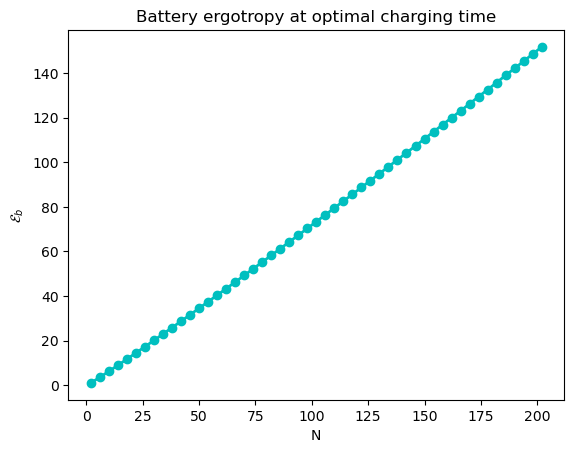

In [4]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

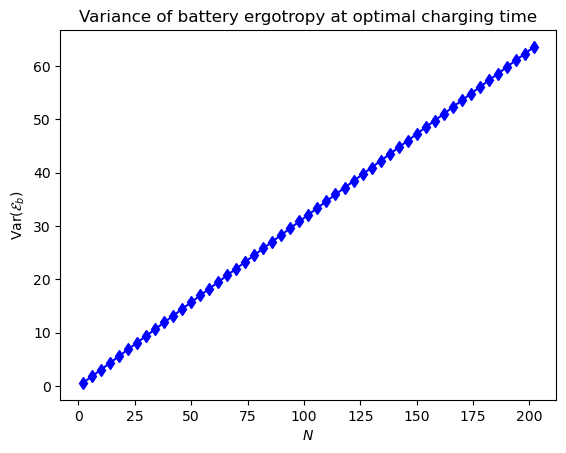

In [5]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

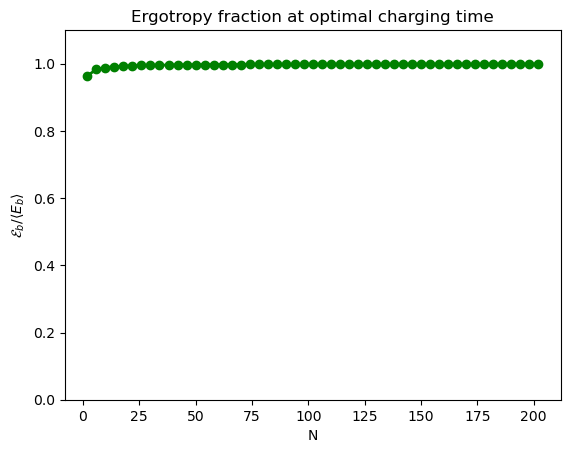

In [6]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

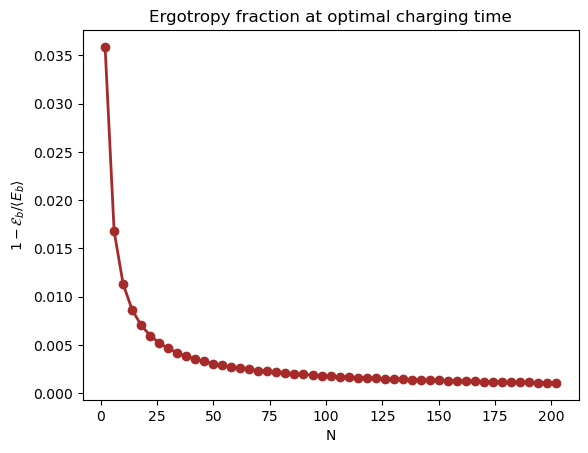

In [7]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, 1 - E_ratio, 'o-', color='brown', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

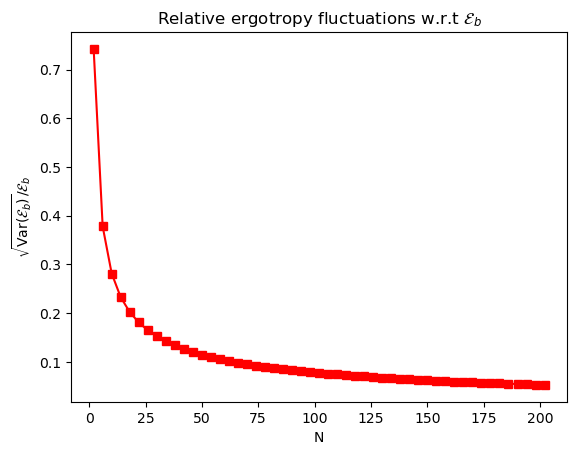

In [8]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

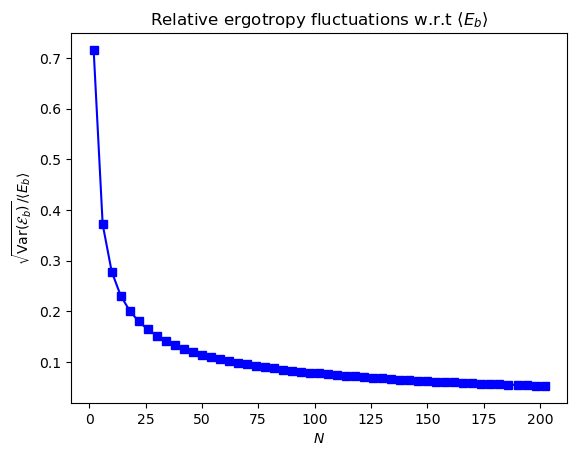

In [9]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

### Scaling of $1 - \mathcal{E}_b / \langle E_b \rangle$

Best fit parameter: A = 0.058444, alpha = 0.758283


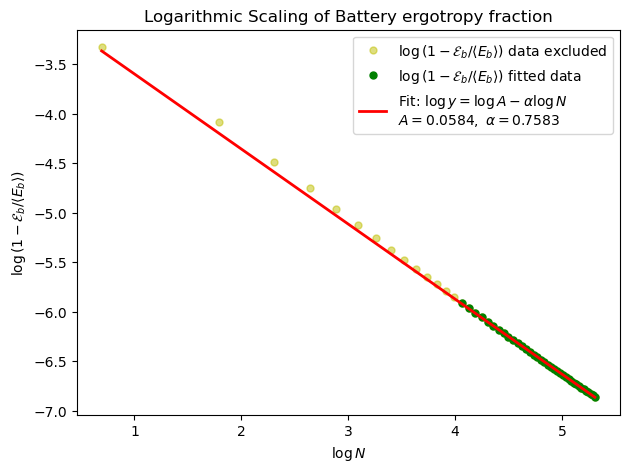

In [20]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[14:51]
y_data1 = y_full[14:51]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title("Logarithmic Scaling of Battery ergotropy fraction")
plt.legend()
plt.show()

### Scaling of $\sqrt var(\mathcal{E}_b) / \mathcal{E}_b$

Best fit parameter: A = 1.027719, alpha = 0.559899


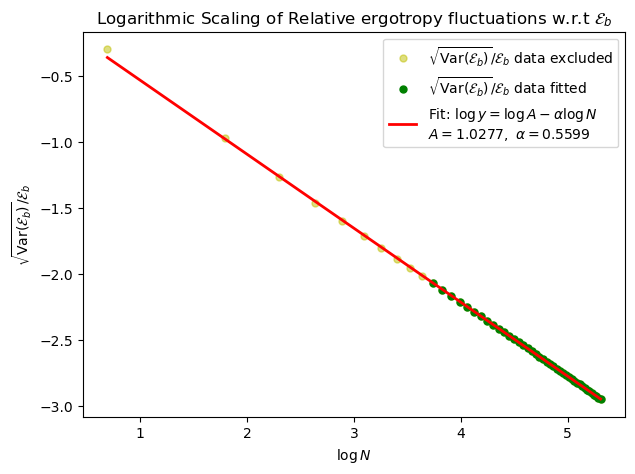

In [19]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit2(log_N, logA, alpha2):
    return logA - alpha2 *log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data2 = N_arr[10:51]
y_data2 = y_full[10:51]

# Keep only positive values for the logarithm
mask = (N_data2 > 0) & (y_data2 > 0)

N_fit2 = N_data2[mask]
y_fit_data2 = y_data2[mask]

# Logarithmic variables
log_N = np.log(N_fit2)
log_y = np.log(y_fit_data2)

# Fit in log-space
popt, pcov = curve_fit(log_fit2, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()